# Encoder 데이터 1분 수집 + 가속도 3종 스윕

`manual_keyboard_balance.ipynb`와 같은 시리얼 인터페이스(`control_comms.py`)를 쓰지만,
모터에는 속도 명령을 보내지 않고 **`CMD_QUERY`만 반복**해서 엔코더 값을 60초 동안 기록한다.

펌웨어가 돌려주는 observation
- `obs[0]` 진자 각도 [deg] (180 deg = 직립)
- `obs[1]` 로터(암) 각도 [deg]
- `obs[2]` 모터 속도 [pps]
- `obs[3]` L6474 상태 레지스터 raw

수집이 끝나면 CSV와 PNG가 `data/`에 저장된다.

> 모터는 hard stop 상태로 두므로 수집 중에 손으로 진자를 튕기거나 암을 돌려서
> 원하는 동작을 만들면 된다. 실행 중 멈추려면 커널 인터럽트(정지 버튼)를 누르면
> 그때까지 모은 데이터는 그대로 남는다.

In [2]:
from control_comms import ControlComms, StatusCode, DebugLevel, find_board_port
from pathlib import Path
from datetime import datetime
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Connection settings
SERIAL_PORT = find_board_port()   # auto-detects the ST-Link port; pass "COM10" to force one
BAUD_RATE = 500000
TIMEOUT = 0.25

# Firmware command IDs (PendulumController.ino)
CMD_SET_HOME = 0
CMD_SET_STEP_MODE = 3
CMD_HARD_STOP = 5
CMD_QUERY = 6
CMD_RESET_SAFETY = 7

STEP_MODE_16 = 4

# Firmware status codes
STATUS_OK = 0
STATUS_MOVING = 1
STATUS_LIMIT = 2
STATUS_DRIVER_FAULT = 3

# Logging settings
DURATION_S = 60.0          # 수집 시간 [s]
SAMPLE_PERIOD_S = 0.02     # 목표 샘플링 주기 (~50 Hz)
PROGRESS_EVERY_S = 5.0     # 진행 상황 출력 간격 [s]
SET_HOME_AT_START = True   # 시작 위치를 rotor 0 deg 로 잡을지 여부

# Windows의 time.sleep() 분해능은 ~15 ms 라 sleep 만으로는 20 ms 주기를 맞출 수 없다.
# 마지막 SPIN_MARGIN_S 구간만 busy-wait 해서 주기를 고정한다 (CPU 부담은 주기당 이 값 이하).
SPIN_MARGIN_S = 0.003

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"{DURATION_S:.0f} s @ {1.0 / SAMPLE_PERIOD_S:.0f} Hz -> 약 {DURATION_S / SAMPLE_PERIOD_S:.0f} 샘플 예상")

Found the board on COM10.
60 s @ 50 Hz -> 약 3000 샘플 예상


In [5]:
# Connect
ctrl = ControlComms(timeout=TIMEOUT, debug_level=DebugLevel.DEBUG_ERROR)
if ctrl.connect(SERIAL_PORT, BAUD_RATE) is not StatusCode.OK:
    raise RuntimeError(f"Could not connect to {SERIAL_PORT}")

# Put the firmware in a known state. 모터는 정지시켜 두고 엔코더만 읽는다.
ctrl.step(CMD_HARD_STOP, [0.0])
ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE_16])
if SET_HOME_AT_START:
    ctrl.step(CMD_SET_HOME, [0.0])
ctrl.step(CMD_RESET_SAFETY, [0.0])

resp = ctrl.step(CMD_QUERY, [0.0])
if resp is None:
    raise RuntimeError("펌웨어가 응답하지 않습니다. USB 케이블과 보드 전원을 확인하세요.")
status, mcu_ms, terminated, obs = resp
print(f"Connected to {SERIAL_PORT}.")
print(f"  status={status}  terminated={terminated}  mcu_t={mcu_ms} ms")
print(f"  pendulum={obs[0]:8.2f} deg   rotor={obs[1]:8.2f} deg   "
      f"motor={obs[2]:7.1f} pps   L6474=0x{int(obs[3]):04X}")

Connected to COM10.
  status=0  terminated=False  mcu_t=933669 ms
  pendulum=  356.70 deg   rotor=    0.00 deg   motor=    0.0 pps   L6474=0xFE03


## 1분 수집

아래 셀을 실행하면 바로 60초 카운트가 시작된다. 사이클마다 `CMD_QUERY`를 한 번 보내고
응답(observation)을 한 행으로 기록한다. 속도(`*_velocity_dps_est`)는 호스트 시각 기준
차분으로 추정한 값이며, 진자 각도는 ±180 deg 경계에서 감기므로 wrap 처리해서 미분한다.

In [11]:
def wrapped_error_deg(angle_deg, setpoint_deg=180.0):
    """직립(180 deg) 기준 오차를 -180..180 deg 로 wrap 해서 반환."""
    return (setpoint_deg - angle_deg + 180.0) % 360.0 - 180.0


records = []
dropped = 0                # 응답이 오지 않은 사이클 수
prev_host_t = None
prev_pendulum = None
prev_rotor = None
first_mcu_ms = None
next_progress = PROGRESS_EVERY_S
cycle = 0

session_start_perf = time.perf_counter()
session_start_wall = time.time()

print(f"엔코더 수집 시작: {DURATION_S:.0f} s (중단하려면 커널 인터럽트)")

try:
    while True:
        loop_start = time.perf_counter()
        if loop_start - session_start_perf >= DURATION_S:
            break

        resp = ctrl.step(CMD_QUERY, [0.0])

        host_elapsed = time.perf_counter() - session_start_perf
        host_unix = time.time()

        if resp is None:
            # 타임아웃/파싱 실패. 이 샘플만 버리고 루프는 계속 돌린다.
            dropped += 1
        else:
            status, mcu_timestamp_ms, terminated, obs = resp
            pendulum_deg = float(obs[0]) if len(obs) > 0 else math.nan
            rotor_deg = float(obs[1]) if len(obs) > 1 else math.nan
            motor_speed_pps = float(obs[2]) if len(obs) > 2 else math.nan
            l6474_status = int(obs[3]) if len(obs) > 3 else -1

            if first_mcu_ms is None:
                first_mcu_ms = int(mcu_timestamp_ms)

            dt = math.nan if prev_host_t is None else host_elapsed - prev_host_t
            pendulum_velocity_dps = math.nan
            rotor_velocity_dps = math.nan
            if prev_host_t is not None and dt > 0:
                dp = (pendulum_deg - prev_pendulum + 180.0) % 360.0 - 180.0
                pendulum_velocity_dps = dp / dt
                rotor_velocity_dps = (rotor_deg - prev_rotor) / dt

            records.append({
                "host_unix_s": host_unix,
                "host_elapsed_s": host_elapsed,
                "host_dt_s": dt,
                "mcu_timestamp_ms": int(mcu_timestamp_ms),
                "mcu_elapsed_s": (int(mcu_timestamp_ms) - first_mcu_ms) / 1000.0,
                "response_status": int(status),
                "terminated": bool(terminated),
                "pendulum_angle_deg": pendulum_deg,
                "pendulum_error_deg": wrapped_error_deg(pendulum_deg),
                "pendulum_velocity_dps_est": pendulum_velocity_dps,
                "rotor_angle_deg": rotor_deg,
                "rotor_velocity_dps_est": rotor_velocity_dps,
                "motor_speed_pps_observed": motor_speed_pps,
                "l6474_status_raw": l6474_status,
            })

            prev_host_t = host_elapsed
            prev_pendulum = pendulum_deg
            prev_rotor = rotor_deg

            if terminated:
                print("펌웨어가 termination/safety 조건을 보고했습니다. 수집을 중단합니다.")
                break

        if host_elapsed >= next_progress:
            print(f"  {host_elapsed:5.1f} s / {DURATION_S:.0f} s   "
                  f"샘플 {len(records)}개   무응답 {dropped}회")
            next_progress += PROGRESS_EVERY_S

        # 고정 격자(session_start + n*T)로 다음 시각을 잡아 주기 오차가 누적되지 않게 한다.
        cycle += 1
        next_deadline = session_start_perf + cycle * SAMPLE_PERIOD_S
        if time.perf_counter() > next_deadline + SAMPLE_PERIOD_S:
            # 한 주기 이상 밀렸으면(시리얼 지연 등) 밀린 만큼 건너뛰고 격자를 다시 맞춘다.
            cycle = int((time.perf_counter() - session_start_perf) / SAMPLE_PERIOD_S) + 1
            next_deadline = session_start_perf + cycle * SAMPLE_PERIOD_S
        while True:
            remaining = next_deadline - time.perf_counter()
            if remaining <= 0:
                break
            if remaining > SPIN_MARGIN_S:
                time.sleep(remaining - SPIN_MARGIN_S)
            # 남은 SPIN_MARGIN_S 는 busy-wait

except KeyboardInterrupt:
    print("사용자 중단. 지금까지 모은 데이터는 그대로 유지됩니다.")

finally:
    # 수집 중에는 구동 명령을 보내지 않았지만, 안전하게 정지 상태로 남겨 둔다.
    try:
        ctrl.step(CMD_HARD_STOP, [0.0])
    except Exception:
        pass

collected_s = records[-1]["host_elapsed_s"] if records else 0.0
rate_hz = len(records) / collected_s if collected_s > 0 else float("nan")
print(f"수집 종료: 샘플 {len(records)}개, {collected_s:.2f} s, "
      f"평균 {rate_hz:.1f} Hz, 무응답 {dropped}회")

엔코더 수집 시작: 60 s (중단하려면 커널 인터럽트)
    5.0 s / 60 s   샘플 251개   무응답 0회
   10.0 s / 60 s   샘플 499개   무응답 0회
   15.0 s / 60 s   샘플 749개   무응답 0회
   20.0 s / 60 s   샘플 999개   무응답 0회
   25.0 s / 60 s   샘플 1249개   무응답 0회
   30.0 s / 60 s   샘플 1499개   무응답 0회
   35.0 s / 60 s   샘플 1749개   무응답 0회
   40.0 s / 60 s   샘플 1997개   무응답 0회
   45.0 s / 60 s   샘플 2244개   무응답 0회
   50.0 s / 60 s   샘플 2494개   무응답 0회
   55.0 s / 60 s   샘플 2744개   무응답 0회
수집 종료: 샘플 2993개, 59.99 s, 평균 49.9 Hz, 무응답 0회


## 저장

In [12]:
if not records:
    raise RuntimeError("기록된 샘플이 없습니다. 연결 셀부터 다시 실행하세요.")

df = pd.DataFrame(records)

stamp = datetime.fromtimestamp(session_start_wall).strftime("%Y%m%d_%H%M%S")
csv_path = DATA_DIR / f"encoder_log_{stamp}.csv"
png_path = DATA_DIR / f"encoder_log_{stamp}.png"

df.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path.resolve()}  ({len(df)} rows)")

display(df.head())
display(df.tail())
display(df[[
    "host_dt_s",
    "pendulum_angle_deg",
    "pendulum_velocity_dps_est",
    "rotor_angle_deg",
    "rotor_velocity_dps_est",
]].describe())

CSV saved: C:\Users\Sim\Dropbox\[Courses]\[고급딥러닝시스템과응용]\08_Claude\Pendulum_control\data\encoder_log_20260914_211953.csv  (2993 rows)


,host_unix_s,host_elapsed_s,host_dt_s,mcu_timestamp_ms,mcu_elapsed_s,response_status,terminated,pendulum_angle_deg,pendulum_error_deg,pendulum_velocity_dps_est,rotor_angle_deg,rotor_velocity_dps_est,motor_speed_pps_observed,l6474_status_raw
0,1.789388e+09,0.010125,NaN,372160,0.000,0,False,0.0,-180.0,NaN,0.0,NaN,0.0,65027
1,1.789388e+09,0.025921,0.015797,372177,0.017,0,False,0.0,-180.0,0.0,0.0,0.0,0.0,65027
2,1.789388e+09,0.046555,0.020634,372197,0.037,0,False,0.0,-180.0,0.0,0.0,0.0,0.0,65027
3,1.789388e+09,0.067686,0.021131,372217,0.057,0,False,0.0,-180.0,0.0,0.0,0.0,0.0,65027
4,1.789388e+09,0.086500,0.018815,372238,0.078,0,False,0.0,-180.0,0.0,0.0,0.0,0.0,65027


,host_unix_s,host_elapsed_s,host_dt_s,mcu_timestamp_ms,mcu_elapsed_s,response_status,terminated,pendulum_angle_deg,pendulum_error_deg,pendulum_velocity_dps_est,rotor_angle_deg,rotor_velocity_dps_est,motor_speed_pps_observed,l6474_status_raw
2988,1.789388e+09,59.907716,0.018556,432547,60.387,0,False,2.4,177.6,0.0,0.0,0.0,0.0,65027
2989,1.789388e+09,59.926261,0.018545,432567,60.407,0,False,2.4,177.6,0.0,0.0,0.0,0.0,65027
2990,1.789388e+09,59.945942,0.019681,432587,60.427,0,False,2.4,177.6,0.0,0.0,0.0,0.0,65027
2991,1.789388e+09,59.968902,0.022960,432607,60.447,0,False,2.4,177.6,0.0,0.0,0.0,0.0,65027
2992,1.789388e+09,59.988728,0.019826,432627,60.467,0,False,2.4,177.6,0.0,0.0,0.0,0.0,65027


,host_dt_s,pendulum_angle_deg,pendulum_velocity_dps_est,rotor_angle_deg,rotor_velocity_dps_est
count,2992.000000,2993.000000,2992.000000,2993.0,2992.0
mean,0.020046,66.160374,0.585244,0.0,0.0
std,0.002723,125.657082,112.227186,0.0,0.0
min,0.005961,0.000000,-614.877023,0.0,0.0
25%,0.019253,2.400000,0.000000,0.0,0.0
50%,0.019916,2.400000,0.000000,0.0,0.0
75%,0.020652,35.400000,0.000000,0.0,0.0
max,0.092780,359.700000,804.300886,0.0,0.0


## 그래프

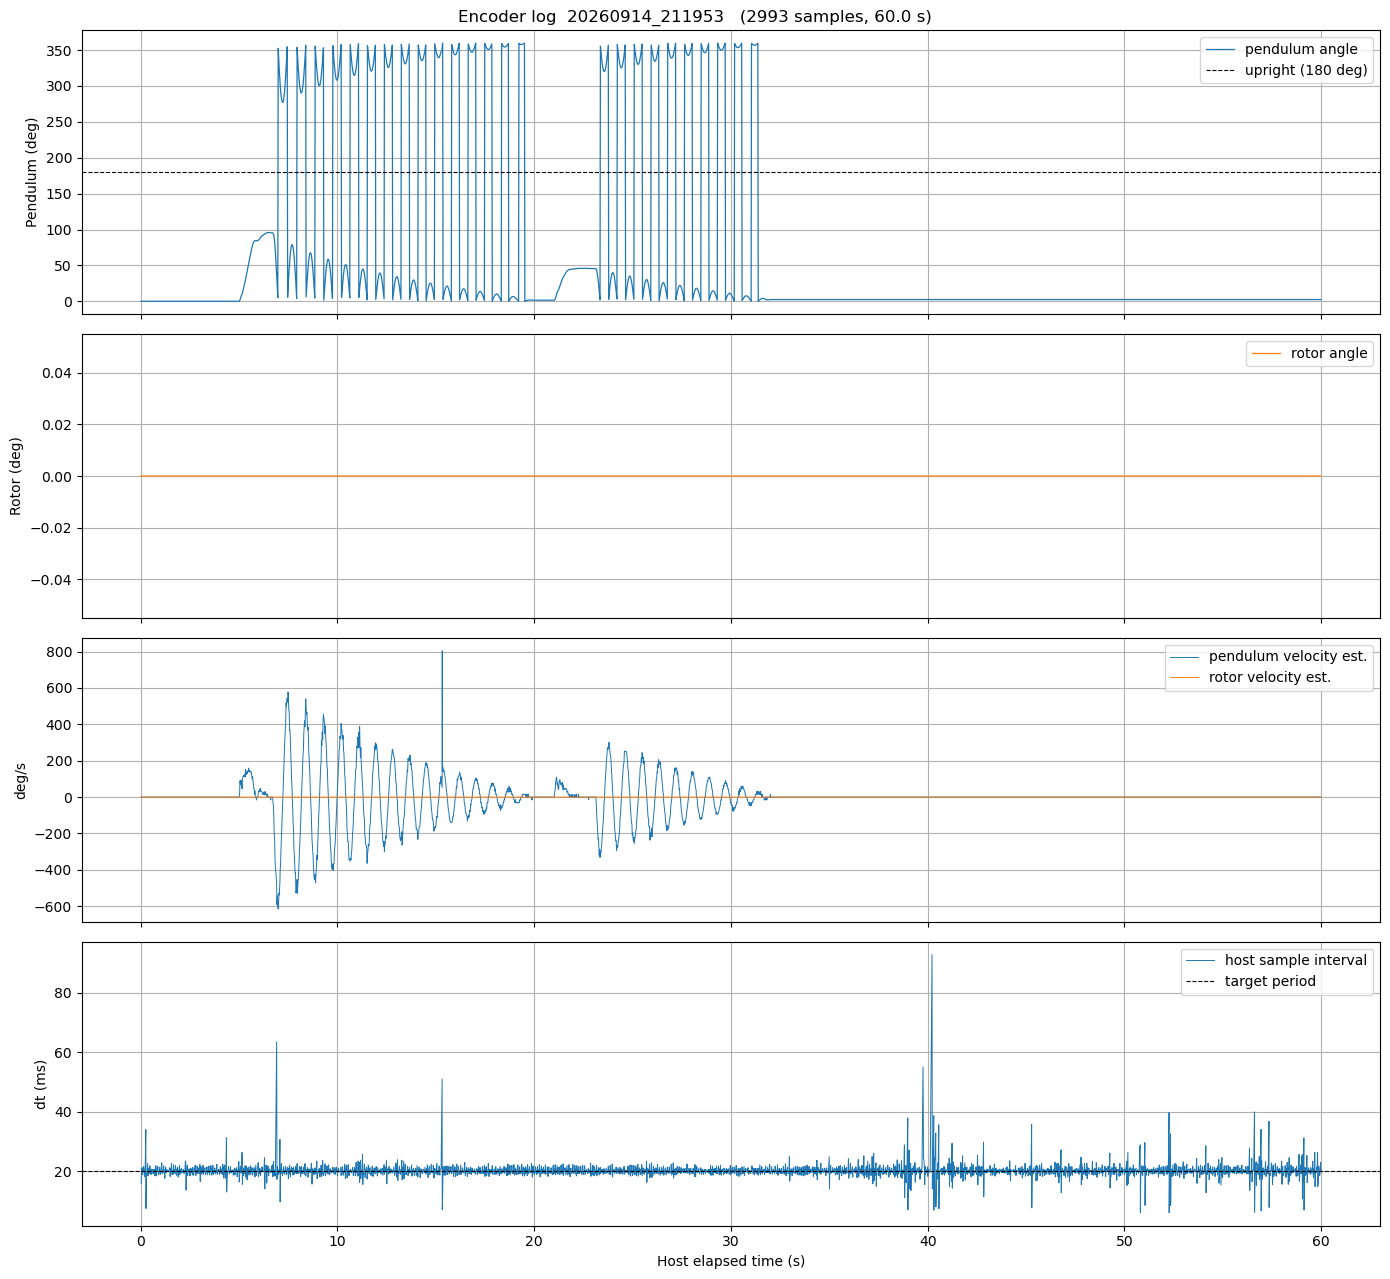

Plot saved: C:\Users\Sim\Dropbox\[Courses]\[고급딥러닝시스템과응용]\08_Claude\Pendulum_control\data\encoder_log_20260914_211953.png


In [13]:
t = df["host_elapsed_s"]

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

axes[0].plot(t, df["pendulum_angle_deg"], lw=0.9, label="pendulum angle")
axes[0].axhline(180.0, ls="--", c="k", lw=0.8, label="upright (180 deg)")
axes[0].set_ylabel("Pendulum (deg)")
axes[0].legend(loc="upper right")
axes[0].grid(True)

axes[1].plot(t, df["rotor_angle_deg"], lw=0.9, c="tab:orange", label="rotor angle")
axes[1].set_ylabel("Rotor (deg)")
axes[1].legend(loc="upper right")
axes[1].grid(True)

axes[2].plot(t, df["pendulum_velocity_dps_est"], lw=0.7, label="pendulum velocity est.")
axes[2].plot(t, df["rotor_velocity_dps_est"], lw=0.7, label="rotor velocity est.")
axes[2].set_ylabel("deg/s")
axes[2].legend(loc="upper right")
axes[2].grid(True)

axes[3].plot(t, df["host_dt_s"] * 1e3, lw=0.7, label="host sample interval")
axes[3].axhline(SAMPLE_PERIOD_S * 1e3, ls="--", c="k", lw=0.8, label="target period")
axes[3].set_ylabel("dt (ms)")
axes[3].set_xlabel("Host elapsed time (s)")
axes[3].legend(loc="upper right")
axes[3].grid(True)

fig.suptitle(f"Encoder log  {stamp}   ({len(df)} samples, {t.iloc[-1]:.1f} s)")
fig.tight_layout()
fig.savefig(png_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Plot saved: {png_path.resolve()}")

## 최하점 기준 각도 (0 deg = 수직 아래)

펌웨어의 `get_encoder_angle()` 은 0..360 deg 를 돌려주기 때문에, 진자가 쉬는 최하점
근처에서 값이 0 과 360 사이를 오가며 위 그래프가 세로로 튄다. 여기서는 ±180 deg 로
wrap 해서 **최하점을 0 deg**, 직립을 ±180 deg 로 두고 다시 그린다. 데이터 자체는 그대로이고
표시 방식만 바꾼 것이다.

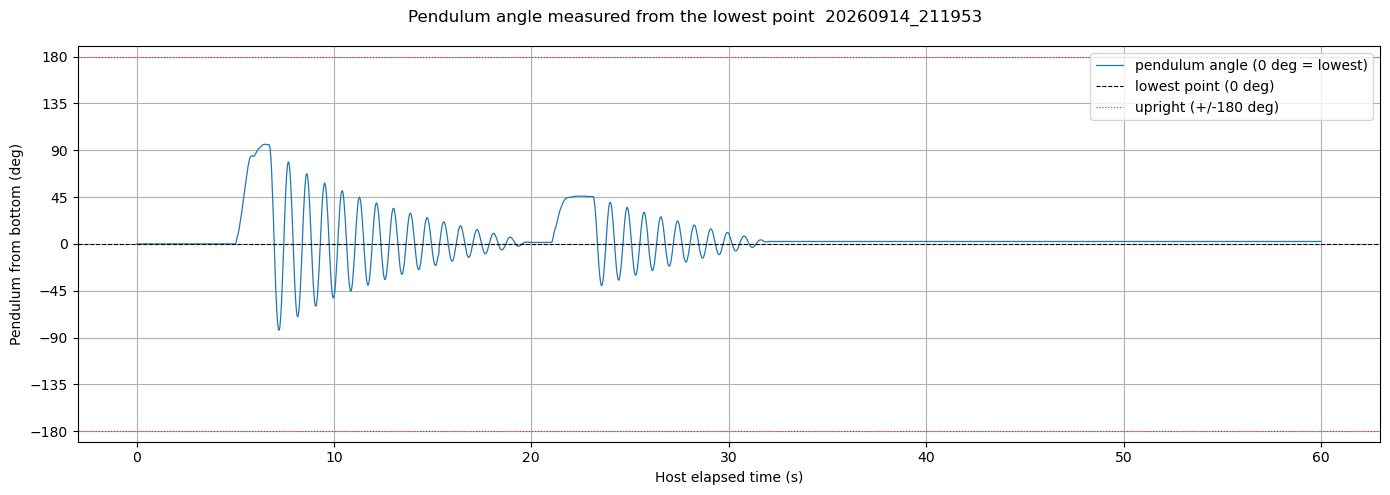

Plot saved: C:\Users\Sim\Dropbox\[Courses]\[고급딥러닝시스템과응용]\08_Claude\Pendulum_control\data\encoder_log_20260914_211953_from_bottom.png
최하점 기준 범위: -82.8 ~ +95.7 deg (평균 +4.9 deg, 최대 진폭 95.7 deg)
이 컬럼은 CSV 저장 뒤에 추가되었다. CSV에도 넣으려면 '저장' 셀을 다시 실행할 것.


In [14]:
# 최하점을 0 deg 로 두고 다시 그린다 (표시용 변환, 원본 값은 그대로).
#   raw 0..360 deg  ->  -180..180 deg :  0 = 최하점, +/-180 = 직립
df["pendulum_from_bottom_deg"] = (df["pendulum_angle_deg"] + 180.0) % 360.0 - 180.0

t = df["host_elapsed_s"]
bottom_png_path = png_path.with_name(png_path.stem + "_from_bottom.png")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, df["pendulum_from_bottom_deg"], lw=0.9, label="pendulum angle (0 deg = lowest)")
ax.axhline(0.0, ls="--", c="k", lw=0.8, label="lowest point (0 deg)")
ax.axhline(180.0, ls=":", c="tab:red", lw=0.8, label="upright (+/-180 deg)")
ax.axhline(-180.0, ls=":", c="tab:red", lw=0.8)
ax.set_ylim(-190.0, 190.0)
ax.set_yticks(range(-180, 181, 45))
ax.set_ylabel("Pendulum from bottom (deg)")
ax.set_xlabel("Host elapsed time (s)")
ax.legend(loc="upper right")
ax.grid(True)

fig.suptitle(f"Pendulum angle measured from the lowest point  {stamp}")
fig.tight_layout()
fig.savefig(bottom_png_path, dpi=160, bbox_inches="tight")
plt.show()

swing = df["pendulum_from_bottom_deg"]
print(f"Plot saved: {bottom_png_path.resolve()}")
print(f"최하점 기준 범위: {swing.min():+.1f} ~ {swing.max():+.1f} deg "
      f"(평균 {swing.mean():+.1f} deg, 최대 진폭 {swing.abs().max():.1f} deg)")
print("이 컬럼은 CSV 저장 뒤에 추가되었다. CSV에도 넣으려면 '저장' 셀을 다시 실행할 것.")

## 샘플링 품질 확인

호스트에서 잰 주기가 목표(`SAMPLE_PERIOD_S`)와 얼마나 맞는지, MCU 타임스탬프와 호스트
시각이 얼마나 벌어졌는지 본다. 평균 주기가 목표보다 꾸준히 길면 시리얼 왕복 지연이 주기를
지배하고 있다는 뜻이므로, `SAMPLE_PERIOD_S`를 실제로 달성되는 값(예: 0.03)까지 올려서
주기를 일정하게 만드는 편이 낫다. 주기가 들쭉날쭉하면 차분으로 구한 속도 추정치의 잡음이
커진다.

샘플 수        : 2920
수집 시간      : 58.608 s
평균 주기      : 20.07 ms  (목표 20.0 ms)
주기 표준편차  : 3.21 ms
최소 / 최대    : 6.18 / 140.36 ms
평균 샘플링률  : 49.8 Hz
무응답 사이클  : 4
host-MCU drift : -457.2 ms (끝점)


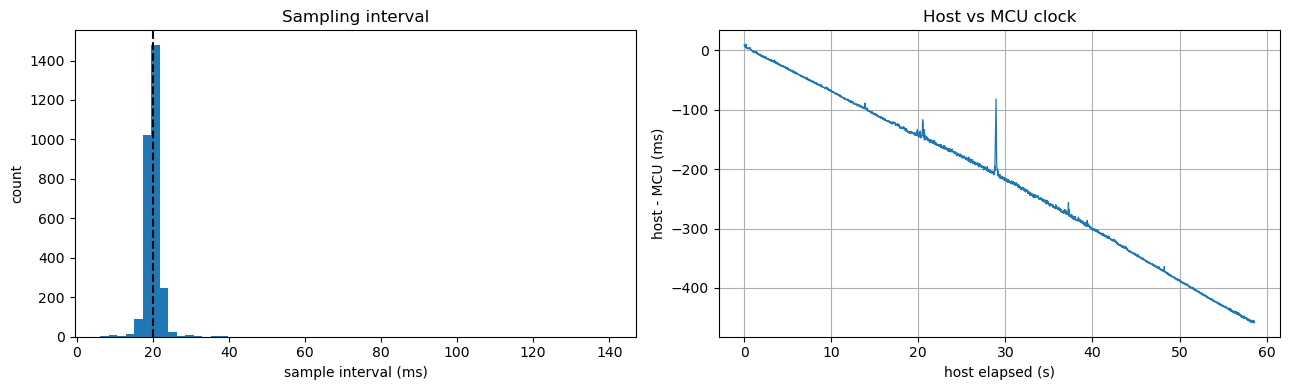

In [9]:
dt_ms = df["host_dt_s"].dropna() * 1e3

print(f"샘플 수        : {len(df)}")
print(f"수집 시간      : {df['host_elapsed_s'].iloc[-1]:.3f} s")
print(f"평균 주기      : {dt_ms.mean():.2f} ms  (목표 {SAMPLE_PERIOD_S * 1e3:.1f} ms)")
print(f"주기 표준편차  : {dt_ms.std():.2f} ms")
print(f"최소 / 최대    : {dt_ms.min():.2f} / {dt_ms.max():.2f} ms")
print(f"평균 샘플링률  : {1e3 / dt_ms.mean():.1f} Hz")
print(f"무응답 사이클  : {dropped}")

# 호스트 시각과 MCU 타임스탬프의 누적 차이 (clock drift + 지연)
drift_ms = (df["host_elapsed_s"] - df["mcu_elapsed_s"]) * 1e3
print(f"host-MCU drift : {drift_ms.iloc[-1]:+.1f} ms (끝점)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(dt_ms, bins=60)
axes[0].axvline(SAMPLE_PERIOD_S * 1e3, ls="--", c="k")
axes[0].set_xlabel("sample interval (ms)")
axes[0].set_ylabel("count")
axes[0].set_title("Sampling interval")

axes[1].plot(df["host_elapsed_s"], drift_ms, lw=0.9)
axes[1].set_xlabel("host elapsed (s)")
axes[1].set_ylabel("host - MCU (ms)")
axes[1].set_title("Host vs MCU clock")
axes[1].grid(True)

fig.tight_layout()
plt.show()

## 가속도 3종 스윕 (1분, 로터/진자 각도 동시 기록)

`PendulumController.ino` 에는 가속도 명령이 없다(`CMD_SET_VELOCITY` = 부호 있는 pps).
그래서 **호스트가 매 주기 속도 지령을 일정한 기울기로 올려서** 가속도를 만든다. 펌웨어의
`set_signed_velocity()` 는 같은 방향으로 도는 동안에는 `set_max_speed()` 만 갱신하므로
이렇게 램프를 걸면 속도가 이어서 변한다.

20초짜리 세그먼트 3개, 각 세그먼트마다 가속도가 다르다. 한 세그먼트는
**+가속 → +감속 → −가속 → −감속 → 정지 후 관찰** 순서의 대칭 프로파일이라
로터가 출발점 근처로 돌아오고, 남은 시간 동안 진자가 어떻게 흔들리다 잦아드는지 볼 수 있다.
최고 속도는 세 세그먼트가 모두 같으므로 가속도 차이만 비교된다.

> 안전
> - 펌웨어의 `ROTOR_LIMIT_ENABLED` 가 false 라 각도 제한이 없다. 여기서는 호스트가
>   `ROTOR_ABORT_DEG` 를 넘는 순간 hard stop 하고 중단한다. 엔코더 케이블이 감기지 않는지
>   눈으로도 확인할 것.
> - 실행 전에 예상 로터 이동량이 먼저 출력된다. 값이 너무 크면 `V_PEAK_PPS` 를 줄이면 된다.
> - 중간에 멈추려면 커널 인터럽트. 그때까지의 데이터는 유지되고 모터는 정지한다.
> - 호스트 주기가 흔들리면 램프가 계단처럼 끊긴다. 속도 지령은 경과 시간으로부터 매번 다시
>   계산하므로 프로파일이 밀리지는 않지만, 실제로 보낸 값은 `command_velocity_pps` 로
>   기록되니 맨 아래 그래프에서 확인할 것.

In [ ]:
# ---- 가속도 3종 스윕: 속도 램프로 가속도를 만들고 로터/진자 각도를 기록 ----

# 이 노트북의 설정 셀은 구동 명령을 쓰지 않아 CMD_SET_VELOCITY 가 없다. 여기서 정의한다.
CMD_SET_VELOCITY = 4           # action = 부호 있는 pps

# PendulumController.ino 의 실제 값 (manual 노트북의 200/1000 은 이 펌웨어와 다름)
FW_MIN_SPEED_PPS = 30.0        # 이보다 작은 지령은 펌웨어가 hard stop 으로 처리
FW_MAX_SPEED_PPS = 4000.0
FW_INTERNAL_ACCEL_PPS2 = 10000.0   # L6474 자체 가감속. 호스트 램프는 이보다 느려야 의미가 있다.

PPS_TO_DPS = 360.0 / (200 * 16)    # STP_STEPS_PER_ROTATION * 1/16 step -> deg per pulse

# 실험 설정
ACCEL_SEGMENTS_PPS2 = [250.0, 750.0, 2250.0]   # 세그먼트별 가속도 (1 : 3 : 9)
SEGMENT_S = 20.0                                # 세그먼트 길이 -> 3 x 20 s = 60 s
V_PEAK_PPS = 500.0                              # 램프 최고 속도
ROTOR_ABORT_DEG = 270.0                         # 호스트 안전 가드 (|rotor| 초과 시 중단)
ACCEL_SAMPLE_PERIOD_S = SAMPLE_PERIOD_S         # 위 로깅과 같은 주기

assert FW_MIN_SPEED_PPS < V_PEAK_PPS <= FW_MAX_SPEED_PPS, "V_PEAK_PPS 가 펌웨어 속도 범위 밖"
assert max(ACCEL_SEGMENTS_PPS2) < FW_INTERNAL_ACCEL_PPS2, "가속도가 L6474 내부 가감속보다 빠름"


def segment_velocity_pps(accel_pps2, t_in_segment):
    """대칭 out-and-back 삼각 속도 프로파일. 0 -> +peak -> 0 -> -peak -> 0 -> 정지."""
    t_ramp = V_PEAK_PPS / accel_pps2
    if t_in_segment < t_ramp:
        return accel_pps2 * t_in_segment
    if t_in_segment < 2.0 * t_ramp:
        return V_PEAK_PPS - accel_pps2 * (t_in_segment - t_ramp)
    if t_in_segment < 3.0 * t_ramp:
        return -accel_pps2 * (t_in_segment - 2.0 * t_ramp)
    if t_in_segment < 4.0 * t_ramp:
        return -V_PEAK_PPS + accel_pps2 * (t_in_segment - 3.0 * t_ramp)
    return 0.0


# 실행 전 예상치. 한쪽 삼각형 면적 = V^2/a [steps] 이 최대 로터 이동량이다.
print(f"총 {len(ACCEL_SEGMENTS_PPS2) * SEGMENT_S:.0f} s, 세그먼트 {SEGMENT_S:.0f} s x {len(ACCEL_SEGMENTS_PPS2)}")
print(f"최고 속도 {V_PEAK_PPS:.0f} pps = {V_PEAK_PPS * PPS_TO_DPS:.1f} deg/s\n")
print(f"{'seg':>3} {'accel[pps^2]':>13} {'[deg/s^2]':>11} {'ramp[s]':>8} {'motion[s]':>10} {'예상 최대 |rotor|[deg]':>22}")
for i, a in enumerate(ACCEL_SEGMENTS_PPS2):
    t_ramp = V_PEAK_PPS / a
    excursion_deg = (V_PEAK_PPS ** 2 / a) * PPS_TO_DPS
    print(f"{i:>3} {a:>13.0f} {a * PPS_TO_DPS:>11.1f} {t_ramp:>8.2f} {4 * t_ramp:>10.2f} {excursion_deg:>22.1f}")
    if excursion_deg > ROTOR_ABORT_DEG:
        print(f"      ! 예상 이동량이 ROTOR_ABORT_DEG({ROTOR_ABORT_DEG:.0f} deg)를 넘는다. V_PEAK_PPS 를 줄일 것.")

# 모터를 멈추고 안전 래치를 푼 뒤, 이 실험의 시작 위치를 rotor 0 deg 로 잡는다.
ctrl.step(CMD_HARD_STOP, [0.0])
ctrl.step(CMD_RESET_SAFETY, [0.0])
ctrl.step(CMD_SET_HOME, [0.0])

records_accel = []
dropped_accel = 0
prev_host_t = None
prev_pendulum = None
prev_rotor = None
first_mcu_ms = None
last_sent_velocity = None
cycle = 0
aborted = None

total_s = SEGMENT_S * len(ACCEL_SEGMENTS_PPS2)
accel_start_perf = time.perf_counter()
accel_start_wall = time.time()
current_segment = -1

print(f"\n가속도 스윕 시작 ({total_s:.0f} s). 중단하려면 커널 인터럽트.")

try:
    while True:
        loop_start = time.perf_counter()
        elapsed_s = loop_start - accel_start_perf
        if elapsed_s >= total_s:
            break

        segment = min(int(elapsed_s / SEGMENT_S), len(ACCEL_SEGMENTS_PPS2) - 1)
        accel_pps2 = ACCEL_SEGMENTS_PPS2[segment]
        t_in_segment = elapsed_s - segment * SEGMENT_S
        if segment != current_segment:
            current_segment = segment
            print(f"  [{elapsed_s:5.1f} s] segment {segment}: accel = {accel_pps2:.0f} pps^2 "
                  f"({accel_pps2 * PPS_TO_DPS:.1f} deg/s^2)")

        # 펌웨어가 실제로 쓰는 값과 맞추려고 1 pps 로 양자화한다.
        requested_velocity = float(round(segment_velocity_pps(accel_pps2, t_in_segment)))
        if abs(requested_velocity) < FW_MIN_SPEED_PPS:
            requested_velocity = 0.0   # 펌웨어가 어차피 hard stop 으로 처리하는 구간

        # 지령이 바뀔 때만 명령을 보내고, 나머지 주기는 query 로 관측만 한다.
        if last_sent_velocity is None or requested_velocity != last_sent_velocity:
            command_sent = CMD_SET_VELOCITY if requested_velocity != 0.0 else CMD_HARD_STOP
            resp = ctrl.step(command_sent, [requested_velocity])
            last_sent_velocity = requested_velocity
        else:
            command_sent = CMD_QUERY
            resp = ctrl.step(CMD_QUERY, [0.0])

        host_elapsed = time.perf_counter() - accel_start_perf
        host_unix = time.time()

        if resp is None:
            dropped_accel += 1
        else:
            status, mcu_timestamp_ms, terminated, obs = resp
            pendulum_deg = float(obs[0]) if len(obs) > 0 else math.nan
            rotor_deg = float(obs[1]) if len(obs) > 1 else math.nan
            motor_speed_pps = float(obs[2]) if len(obs) > 2 else math.nan
            l6474_status = int(obs[3]) if len(obs) > 3 else -1

            if first_mcu_ms is None:
                first_mcu_ms = int(mcu_timestamp_ms)

            dt = math.nan if prev_host_t is None else host_elapsed - prev_host_t
            pendulum_velocity_dps = math.nan
            rotor_velocity_dps = math.nan
            if prev_host_t is not None and dt > 0:
                dp = (pendulum_deg - prev_pendulum + 180.0) % 360.0 - 180.0
                pendulum_velocity_dps = dp / dt
                rotor_velocity_dps = (rotor_deg - prev_rotor) / dt

            records_accel.append({
                "host_unix_s": host_unix,
                "host_elapsed_s": host_elapsed,
                "host_dt_s": dt,
                "mcu_timestamp_ms": int(mcu_timestamp_ms),
                "mcu_elapsed_s": (int(mcu_timestamp_ms) - first_mcu_ms) / 1000.0,
                "response_status": int(status),
                "terminated": bool(terminated),
                "segment": int(segment),
                "accel_cmd_pps2": float(accel_pps2),
                "t_in_segment_s": t_in_segment,
                "command_id_sent": int(command_sent),
                "command_velocity_pps": requested_velocity,
                "pendulum_angle_deg": pendulum_deg,
                "pendulum_from_bottom_deg": (pendulum_deg + 180.0) % 360.0 - 180.0,
                "pendulum_velocity_dps_est": pendulum_velocity_dps,
                "rotor_angle_deg": rotor_deg,
                "rotor_velocity_dps_est": rotor_velocity_dps,
                "motor_speed_pps_observed": motor_speed_pps,
                "l6474_status_raw": l6474_status,
            })

            prev_host_t = host_elapsed
            prev_pendulum = pendulum_deg
            prev_rotor = rotor_deg

            # 호스트 안전 가드: 펌웨어 소프트 리밋이 꺼져 있으므로 여기서 막는다.
            if abs(rotor_deg) > ROTOR_ABORT_DEG:
                aborted = f"로터가 {rotor_deg:+.1f} deg (한계 {ROTOR_ABORT_DEG:.0f} deg)"
                break
            if terminated or status in (STATUS_LIMIT, STATUS_DRIVER_FAULT):
                aborted = f"펌웨어 status={status}, terminated={terminated}"
                break

        # 고정 격자 페이싱 (로깅 셀과 동일)
        cycle += 1
        next_deadline = accel_start_perf + cycle * ACCEL_SAMPLE_PERIOD_S
        if time.perf_counter() > next_deadline + ACCEL_SAMPLE_PERIOD_S:
            cycle = int((time.perf_counter() - accel_start_perf) / ACCEL_SAMPLE_PERIOD_S) + 1
            next_deadline = accel_start_perf + cycle * ACCEL_SAMPLE_PERIOD_S
        while True:
            remaining = next_deadline - time.perf_counter()
            if remaining <= 0:
                break
            if remaining > SPIN_MARGIN_S:
                time.sleep(remaining - SPIN_MARGIN_S)

except KeyboardInterrupt:
    aborted = "사용자 중단"

finally:
    try:
        ctrl.step(CMD_HARD_STOP, [0.0])
    except Exception:
        pass

if aborted:
    print(f"!! 중단됨: {aborted}. 모터는 정지시켰습니다.")

df_accel = pd.DataFrame(records_accel)
if df_accel.empty:
    raise RuntimeError("기록된 샘플이 없습니다.")

accel_stamp = datetime.fromtimestamp(accel_start_wall).strftime("%Y%m%d_%H%M%S")
accel_csv_path = DATA_DIR / f"accel_sweep_{accel_stamp}.csv"
accel_png_path = DATA_DIR / f"accel_sweep_{accel_stamp}.png"
df_accel.to_csv(accel_csv_path, index=False)

collected_s = df_accel["host_elapsed_s"].iloc[-1]
print(f"\n수집 종료: 샘플 {len(df_accel)}개, {collected_s:.1f} s, "
      f"평균 {len(df_accel) / collected_s:.1f} Hz, 무응답 {dropped_accel}회")
print(f"CSV saved: {accel_csv_path.resolve()}")

# 세그먼트별 요약: 가속도가 커질수록 진자가 얼마나 더 세게 걷어차이는지
summary = df_accel.groupby(["segment", "accel_cmd_pps2"]).agg(
    pendulum_max_abs_deg=("pendulum_from_bottom_deg", lambda s: s.abs().max()),
    pendulum_max_rate_dps=("pendulum_velocity_dps_est", lambda s: s.abs().max()),
    rotor_max_abs_deg=("rotor_angle_deg", lambda s: s.abs().max()),
    rotor_net_deg=("rotor_angle_deg", lambda s: s.iloc[-1] - s.iloc[0]),
    motor_peak_pps=("motor_speed_pps_observed", lambda s: s.abs().max()),
)
display(summary)

# ---- 그래프 ----
ta = df_accel["host_elapsed_s"]
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for seg, a in enumerate(ACCEL_SEGMENTS_PPS2):
    x0, x1 = seg * SEGMENT_S, min((seg + 1) * SEGMENT_S, collected_s)
    if x0 >= collected_s:
        break
    for ax in axes:
        ax.axvspan(x0, x1, color="tab:blue" if seg % 2 == 0 else "tab:orange", alpha=0.06)
    axes[0].annotate(f"{a:.0f} pps$^2$", xy=((x0 + x1) / 2, 0.03), xycoords=("data", "axes fraction"),
                     ha="center", va="bottom", fontsize=9)

axes[0].plot(ta, df_accel["pendulum_from_bottom_deg"], lw=0.9, label="pendulum (0 deg = lowest)")
axes[0].axhline(0.0, ls="--", c="k", lw=0.8)
axes[0].set_ylabel("Pendulum (deg)")
axes[0].legend(loc="upper right")
axes[0].grid(True)

axes[1].plot(ta, df_accel["rotor_angle_deg"], lw=0.9, c="tab:green", label="rotor angle")
axes[1].axhline(0.0, ls="--", c="k", lw=0.8)
axes[1].set_ylabel("Rotor (deg)")
axes[1].legend(loc="upper right")
axes[1].grid(True)

axes[2].plot(ta, df_accel["command_velocity_pps"], lw=1.0, label="commanded velocity")
axes[2].plot(ta, df_accel["motor_speed_pps_observed"], lw=0.8, alpha=0.8, label="observed motor speed")
axes[2].set_ylabel("pps")
axes[2].set_xlabel("Host elapsed time (s)")
axes[2].legend(loc="upper right")
axes[2].grid(True)

fig.suptitle(f"Acceleration sweep  {accel_stamp}   "
             f"{' / '.join(f'{a:.0f}' for a in ACCEL_SEGMENTS_PPS2)} pps$^2$")
fig.tight_layout()
fig.savefig(accel_png_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Plot saved: {accel_png_path.resolve()}")

## 연결 종료

다른 노트북(예: `manual_keyboard_balance.ipynb`)에서 같은 포트를 쓰려면 반드시 닫아야 한다.

In [17]:
ctrl.step(CMD_HARD_STOP, [0.0])
ctrl.close()
print("Serial port closed.")

RuntimeError: Serial port is not open